In [1]:
!pip install astropy
!pip install lenstronomy
!pip install git+https://github.com/LSSTDESC/gcr-catalogs.git
!pip install healpy
!python -m GCRCatalogs.user_config set root_dir /global/cfs/projectdirs/deepsrch/cosmo_dc2/

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package install

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from lenstronomy.LightModel.Profiles.interpolation import Interpol
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.Util.param_util import phi_q2_ellipticity,ellipticity2phi_q
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util.analysis_util import half_light_radius
import scipy.optimize as opt
from scipy.stats import norm, uniform, truncnorm
import glob, tqdm
import pandas as pd

In [3]:
size=".5-1.5"
# size=".15-.5"
# size=".02-.15"

home = "/global/cfs/projectdirs/deepsrch/jwst_sims/data/"
#Path to VELA download
vela_path = '/global/cfs/projectdirs/deepsrch/vela'

In [4]:
#Loads CosmoDC2 catalog
import GCRCatalogs
cat = GCRCatalogs.load_catalog("desc_cosmodc2")
keys = ['redshift', 'halo_mass', 'stellar_mass', 'size_true', 'ellipticity_1_true', 'ellipticity_2_true', 'is_central']
dc2 = cat.get_quantities(keys)

#size limits to help with speed and theta_E distributions
if size=='.5-1.5':
    inds = dc2['is_central']*(dc2['halo_mass']>1e13)
elif size=='.15-.5':
    inds = dc2['is_central']*(dc2['halo_mass']>5e12)*(dc2['halo_mass']<5e13)
elif size=='.02-.15':
    inds = dc2['is_central']*(dc2['halo_mass']>1e10)*(dc2['halo_mass']<5e12)

ms = cat.get_quantities('stellar_mass')['stellar_mass']
for key in keys:
    dc2[key] = dc2[key][inds]
zinds = np.arange(len(dc2['redshift']))
np.random.shuffle(zinds)

zs_dc2 = dc2['redshift']

#Masses created using lens_forecast.ipynb
ms_dict = np.load(home+'zahid_ms.npz')
#Decreases mass range for .15-.5
if size==".15-.5":
    size=".05-.5"
sizes = np.array(ms_dict.files)
low, up = np.array([float(_) for _ in size.split('-')])
sizes_f = [float(_) for _ in sizes]
sizes = sizes[(sizes_f>=low)*(sizes_f<up)]
if size==".05-.5":
    size=".15-.5"

In [5]:
def stellar_mass(M, z):
    mM10 = 11.88
    mu = 0.019
    mM00 = 0.0282
    nu = -0.72
    gamma0 = 0.556
    gamma1 = -0.26
    beta0 = 1.06
    beta1 = 0.17
    
    M1=10**(11.88*(z+1)**mu)
    mM0=mM00*(z+1)**nu
    gamma = gamma0*(z+1)**gamma1
    beta = beta1*z+beta0
    shmr = 2*mM0/((M/M1)**(-beta)+(M/M1)**gamma)
    return shmr * M

def mHalo(m, z):
    if z<.5:
        M1 = 10**12.629
        M0 = 10**10.855
        beta=0.487
        delta=0.935
        gamma=1.939
    elif z<.8:
        M1 = 10**12.793
        M0 = 10**10.927
        beta=0.502
        delta=0.802
        gamma=3.132    
    elif z < 1.1:
        M1 = 10**12.730
        M0 = 10**11.013
        beta=0.454
        delta=1.109
        gamma=1.925    
    elif z < 1.5:
        M1 = 10**12.673
        M0 = 10**10.967
        beta=0.393
        delta=0.746
        gamma=0.335    
    elif z < 2.0:
        M1 = 10**12.787
        M0 = 10**11.040
        beta=0.410
        delta=0.716
        gamma=1.312   
    elif z < 2.5:
        M1 = 10**13.097
        M0 = 10**11.254
        beta=0.495
        delta=0.668
        gamma=1.077    
    elif z < 3.0:
        M1 = 10**12.627
        M0 = 10**10.920
        beta=0.393
        delta=0.274
        gamma=0.447   
    elif z < 3.5:
        M1 = 10**12.820
        M0 = 10**11.067
        beta=0.465
        delta=0.354
        gamma=0.741    
    elif z < 4.5:
        M1 = 10**13.638
        M0 = 10**12.222
        beta=0.551
        delta=1.557
        gamma=3.149    
    else:
        M1 = 10**13.547
        M0 = 10**12.105
        beta=0.567
        delta=1.427
        gamma=3.225    
                        
    Mhalo = 10**(np.log10(M1)+beta*np.log10(m/M0)+((m/M0)**delta)/(1+(m/M0)**(-gamma))-1/2)
    return Mhalo

#Loads VELA catalog
vela_cat = pd.read_csv(home+"JWST/hlsp_vela_multi_multi_vela_multi_v3_cat.txt", delim_whitespace=True)
vela_cat

/tmp/ipykernel_1775757/3730092318.py:84: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  vela_cat = pd.read_csv(home+"JWST/hlsp_vela_multi_multi_vela_multi_v3_cat.txt", delim_whitespace=True)


,sim,z,scale,cam,mission,instrument,filter,flux_njy,abmag,mstar,mgas,mmet,sfr,mvir_dm,path
0,vela01,19.000000,0.05,cam00,hst,acs,f435w,0.000000e+00,NaN,2.713491e+05,8.672512e+10,5.582583e+02,0.317644,2.430748e+08,vela/vela01/cam00/hst/acs/f435w/hlsp_vela_hst_...
1,vela01,15.666667,0.06,cam00,hst,acs,f435w,1.916872e-32,110.693583,1.292812e+06,6.287650e+10,1.109931e+04,0.249550,5.074384e+08,vela/vela01/cam00/hst/acs/f435w/hlsp_vela_hst_...
2,vela01,13.285714,0.07,cam00,hst,acs,f435w,8.964136e-27,96.518795,2.304172e+06,5.971775e+10,2.083764e+04,0.975671,1.172963e+09,vela/vela01/cam00/hst/acs/f435w/hlsp_vela_hst_...
3,vela01,11.500000,0.08,cam00,hst,acs,f435w,3.324756e-23,87.595666,6.421828e+06,4.147531e+10,6.125115e+04,1.051829,2.250957e+09,vela/vela01/cam00/hst/acs/f435w/hlsp_vela_hst_...
4,vela01,10.111111,0.09,cam00,hst,acs,f435w,1.504973e-19,78.456244,1.317297e+07,3.853616e+10,1.457750e+05,2.183615,3.149162e+09,vela/vela01/cam00/hst/acs/f435w/hlsp_vela_hst_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
807018,vela35,8.090909,0.11,cam18,wfirst,wfidrm15,z087,2.062675e-02,35.613989,2.376371e+08,4.918993e+10,2.291054e+06,14.120490,3.063316e+10,vela/vela35/cam18/wfirst/wfidrm15/z087/hlsp_ve...
807019,vela35,7.333333,0.12,cam18,wfirst,wfidrm15,z087,2.558612e-01,32.880055,3.429454e+08,3.890345e+10,2.956734e+06,30.825400,4.156953e+10,vela/vela35/cam18/wfirst/wfidrm15/z087/hlsp_ve...
807020,vela35,6.692308,0.13,cam18,wfirst,wfidrm15,z087,5.853500e+00,29.481526,6.192816e+08,3.175911e+10,4.611881e+06,27.574380,5.302207e+10,vela/vela35/cam18/wfirst/wfidrm15/z087/hlsp_ve...
807021,vela35,6.142857,0.14,cam18,wfirst,wfidrm15,z087,2.230114e+01,28.029248,9.749514e+08,3.329994e+10,6.080173e+06,50.632260,6.498438e+10,vela/vela35/cam18/wfirst/wfidrm15/z087/hlsp_ve...


In [6]:
#Williams et al. (2018) JWST image and catalogs
with fits.open(home+'JWST/goods_s_F115W_2018_08_29.fits') as hdul:
    header = hdul[0].header
    sim = hdul[0].data * header['GAIN']
wcs = WCS(header)

with fits.open(home+'JWST/JADES_SF_mock_r1_v1.1.fits') as hdul:
    data_sf = hdul[1].data
with fits.open(home+'JWST/JADES_Q_mock_r1_v1.1.fits') as hdul:
    data_q = hdul[1].data

#limits of rectangle used:
#dec = [-27.83, -27.785]
#ra = [53.137, 53.222]

cut_sf= data_sf[data_sf['RA']>53.137]
cut_sf = cut_sf[cut_sf['RA']<53.222]
cut_sf = cut_sf[cut_sf['DEC']>-27.83]
cut_sf = cut_sf[cut_sf['DEC']<-27.785]
cut_q= data_q[data_q['RA']>53.137]
cut_q = cut_q[cut_q['RA']<53.222]
cut_q = cut_q[cut_q['DEC']>-27.83]
cut_q = cut_q[cut_q['DEC']<-27.785]

#scaling factor:
#1 unit of the simulations is 1/sum_to_flux=1/6.501853565914121=0.15380229497054293 nJy
sum_to_flux = 6.501853565914121
#Mass to Light ratio (calculated from Williams et al. (2018) catalog)
def ML_ratio(z):
    return 10**(2.15259223299506*np.log10(z)+6.61731435158865)

In [7]:
velas = glob.glob(vela_path+'/vela01/cam00/jwst/nircam/f115w/*')
velas.sort()
redshifts = np.zeros(len(velas))
for i in range(len(velas)):
    with fits.open(velas[i]) as hdul:
        vela_h = hdul[0].header
        vela_d = hdul[0].data
        redshifts[i] = vela_h['REDSHIFT']
#Chooses only the random cams
cams = np.array(["cam12", "cam13", "cam14", "cam15", "cam16", "cam17", "cam18"])
sims = glob.glob(vela_path+'/*')
sims = np.array([sim[-6:] for sim in sims])
redshifts

array([19.   , 15.667, 13.286, 11.5  , 10.111,  8.091,  7.333,  6.692,
        6.143,  5.667,  5.25 ,  4.882,  4.263,  4.   ,  3.762,  3.545,
        3.348,  3.167,  3.   ,  2.846,  2.704,  2.571,  2.448,  2.333,
        2.226,  2.125,  2.03 ,  1.941,  1.857,  1.778,  1.703,  1.632,
        1.564,  1.5  ,  1.439,  1.381,  1.326,  1.273,  1.222,  1.174,
        1.128,  1.083,  1.041,  1.   ])

In [8]:
#Kwargs setup
pixels = vela_d.shape[0]
pixel_size = vela_h['PIXSCALE']

background_rms = header['BKG']

lens_light_model_class = LightModel(['SERSIC_ELLIPSE'])
lens_model_class = LensModel(['SIE'], z_lens=1, z_source=6)

kwargs_lens = [{'theta_E':0, 'e1':0, 'e2':0, 'center_x': 0, 'center_y': 0}]
kwargs_lens_light = [{'amp':1, 'R_sersic': 1, 'n_sersic': 2, 'e1':0, 'e2':0, 'center_x': 0, 'center_y': 0}]

In [ ]:
# ── Real JWST F115W backgrounds ───────────────────────────────────────────
# Replaces sim_background() with real NIRCam sky patches extracted from
# program jw01810 (observation 2).  Patches are background-subtracted and
# stored in MJy/sr units; we convert to simulation flux units here.
#
# Conversion:  sim_unit = (MJy/sr) × PIXAR_SR × 1e15 × sum_to_flux
#   PIXAR_SR = 2.292e-14 sr/pix  (from FITS header keyword PIXAR_SR)
#   sum_to_flux = 6.502  (calibrated in cell above)
#   → scale ≈ 149.0  (MJy/sr per pixel → simulation flux units)
#
# Update REAL_BG_PATH to wherever you put the prepped/ folder in this repo.

REAL_BG_PATH = home + "JWST/prepped/real_backgrounds.npy"

real_bgs = np.load(REAL_BG_PATH)

PIXAR_SR       = 2.29232933396454e-14          # sr per pixel (FITS header)
mjysr_to_sim   = PIXAR_SR * 1e15 * sum_to_flux # ≈ 149.0
real_bgs_sim   = (real_bgs * mjysr_to_sim).astype(np.float32)

print(f"Loaded {len(real_bgs_sim)} real JWST background patches.")
print(f"Unit conversion factor (MJy/sr → sim units): {mjysr_to_sim:.2f}")

_bg_rng = np.random.default_rng()

def get_real_background():
    """Return a random real JWST F115W background patch in simulation flux units."""
    return real_bgs_sim[_bg_rng.integers(len(real_bgs_sim))]


In [9]:
def sim_background(exp_time=10000, inds=range(len(cut_sf))):
    inds = inds
    pixels = 125
    exp_time = exp_time
    
    #lenstronomy setup
    bright = cut_sf[np.random.choice(inds)]
    kwargs_data = {'background_rms': background_rms, 'exposure_time': exp_time,
                   'ra_at_xy_0': -pixels/2*pixel_size, 'dec_at_xy_0': -pixels/2*pixel_size,
                   'transform_pix2angle':np.array([[pixel_size, 0.  ], [0.  , pixel_size]]), 
                   'image_data': np.zeros((pixels, pixels))}

    kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

    data_class = ImageData(**kwargs_data)

    #PSF
    kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': 0.03, 'pixel_size': pixel_size, 'truncation': 3}
    psf_class = PSF(**kwargs_psf)

    kwargs_source = []

    #this section selects the galaxies in a cutout around a random galaxy
    #rad=radius of the cutout
    rad = pixels*pixel_size/2/3600
    #location of random central galaxy
    ra, dec = bright['RA'], bright['DEC']
    #gals = group of galaxies in cutout
    gals = cut_sf[cut_sf['RA']>ra-rad]
    gals = gals[gals['RA']<ra+rad]
    gals = gals[gals['DEC']>dec-rad]
    gals = gals[gals['DEC']<dec+rad]
    source_model_class1 = LightModel(['INTERPOL'])
    image_model1 = ImageModel(data_class=data_class, psf_class=psf_class, lens_model_class=lens_model_class, 
        source_model_class=source_model_class1, lens_light_model_class=lens_light_model_class,
        kwargs_numerics=kwargs_numerics)

    kwargs_lens[0]['theta_E'] = 0
    models = []
    
    #adds each environmental galaxy to the simulation
    for galind in range(len(gals)):
        center_x, center_y = norm.rvs(loc=0, scale=0.25, size=2)
        #uses a VELA object as the environmental source with 20% chance
        if np.random.random()>.8:
            #random VELA sim and cam
            sim = np.random.choice(sims)
            cam = np.random.choice(cams)

            #chooses closest redshift to the Williams+ galaxy
            redshifts = glob.glob(vela_path+'/'+sim+'/'+cam+'/jwst/nircam/f115w/*')
            redshifts = np.array([1/(int(r[107:110])/1000)-1 for r in redshifts])
            redshifts = np.sort(redshifts)[::-1]
            i = np.argmin(np.abs(redshifts-gals[galind]['redshift']))

            velas = glob.glob(vela_path+'/'+sim+'/'+cam+'/jwst/nircam/f115w/*')
            velas.sort()
            vela_d = fits.open(velas[i])[0].data
            #offset of galaxy in ra and dec from center
            dra, ddec = (gals[galind]['RA'] - ra)*3600, (gals[galind]['DEC'] - dec)*3600
            ks_temp = [{'image':vela_d, 'amp':1, 'scale':pixel_size, 'center_x':0, 'center_y':0}]
           
            #calculates total pixel sum of the galaxy to set the right amplitude
            flux = gals[galind]['NRC_F115W_fnu']
            query = vela_cat.query("sim=='"+sim+"' and cam=='"+cam+"' and z==%.8f and filter=='f115w'" % np.round(redshifts[i],8))
            if len(query)==0:
                return sim_background(exp_time=exp_time, inds=inds)
            vflux = query['flux_njy'].values[0]
            #calc_sum = desired pixel sum (flux) of the galaxy
            calc_sum = sum_to_flux * flux
            factor = norm.rvs(loc=0, scale=.7)
            #brightness increase to help neural network recognize bright environmental galaxies
            calc_sum *= 10**factor

            data_class = ImageData(**kwargs_data)
            source_model_class1 = LightModel(['INTERPOL'])
            image_model1 = ImageModel(data_class=data_class, psf_class=psf_class, lens_model_class=lens_model_class, 
                source_model_class=source_model_class1, lens_light_model_class=lens_light_model_class,
                kwargs_numerics=kwargs_numerics)
            image = image_model1.image(kwargs_lens, ks_temp, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None,
                                       source_add=True, lens_light_add=False)
            
            pixs = np.arange(image.shape[0])
            #sersic radius of the VELA image
            re = half_light_radius(image, x_grid = pixs, y_grid = pixs, center_x=np.mean(pixs),center_y=np.mean(pixs))
            
            #rad_rat = ratio of the circularized radius of the Williams galaxy to the VELA galaxy
            rad_rat = np.sqrt(gals[galind]['Re_maj']**2*gals[galind]['axis_ratio'])/(re*pixel_size)
            #scales image up/down to roughly match the right angular size
            ks_temp[0]['scale'] = ks_temp[0]['scale']*rad_rat
            image = image_model1.image(kwargs_lens, ks_temp, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None,
                source_add=True, lens_light_add=False)
            
            #sets x and y from dra, ddec offsets foudn before
            ks_temp[0]['center_x']=center_x-dra
            ks_temp[0]['center_y']=center_y+ddec
            #rare bug caused no flux: just re-generates in that case
            if np.sum(image)==0:
                return sim_background(exp_time=exp_time, inds=inds)
            #scales amplitude to set the proper total pixel sum of the galaxy
            ks_temp[0]['amp'] = calc_sum/np.sum(image)
            
            #appends the kwargs and model to the full source model
            kwargs_source.append(ks_temp[0])
            models.append('INTERPOL')
            
        #uses a Sersic ellipse as the environmental source with 80% chance
        else:
            #offset of galaxy in ra and dec from center
            dra, ddec = (gals[galind]['RA'] - ra)*3600, (gals[galind]['DEC'] - dec)*3600
            #randomly samples Sersic parameters
            n_sersic = uniform.rvs(loc=2, scale=4)
            R_sersic = gals[galind]['Re_maj']
            e1, e2 = truncnorm.rvs(-3, 3, loc=0, scale=0.05, size = 2)
            ks_temp = [{'amp':1, 'R_sersic': R_sersic, 'n_sersic': n_sersic, 'e1':e1, 'e2':e2, 'center_x':center_x-dra, 'center_y':center_y+ddec}]
            #calc_sum = desired pixel sum (flux) of the galaxy
            calc_sum = sum_to_flux * gals[galind]['NRC_F115W_fnu']
            
            factor = norm.rvs(loc=0, scale=.7)
            #brightness increase to help neural network recognize bright environmental galaxies
            calc_sum *= 10**factor
            
            source_model_class1 = LightModel(['SERSIC_ELLIPSE'])
            image_model1 = ImageModel(data_class=data_class, psf_class=psf_class, lens_model_class=lens_model_class, 
                source_model_class=source_model_class1, lens_light_model_class=lens_light_model_class,
                kwargs_numerics=kwargs_numerics)
            image = image_model1.image(kwargs_lens, ks_temp, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None,
                                       source_add=True, lens_light_add=False)
            #scales amplitude to set the proper total pixel sum of the galaxy
            ks_temp[0]['amp'] = calc_sum/np.sum(image)
            
            #appends the kwargs and model to the full source model
            kwargs_source.append(ks_temp[0])
            models.append('SERSIC_ELLIPSE')

    #generates the full image with all of the environmental galaxies    
    source_model_class = LightModel(models)
    image_model = ImageModel(data_class=data_class, psf_class=psf_class, lens_model_class=lens_model_class, 
        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
        kwargs_numerics=kwargs_numerics)
    image =image_model.image(kwargs_lens, kwargs_source, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None,
                               source_add=True, lens_light_add=False)
    
    # #adds noise if desired
    # poisson = image_util.add_poisson(image, exp_time=exp_time) * 0
    # bkg = image_util.add_background(image, sigma_bkd=background_rms)
    # return image + poisson + bkg
    return image

# #Can test displaying a 5x5 of background
# fig, axs=plt.subplots(5,5, figsize=(20,20))
# for j in range(25):
#     image_real = sim_background()
#     axs[j//5,j%5].imshow(image_real, vmin=0, vmax=np.sqrt(np.max(image_real)*np.mean(image_real))/1.5)
#     axs[j//5,j%5].axis('off')
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.0,wspace=0.0)

In [ ]:
#5x5 test of simulation code
fig, axs = plt.subplots(5,5, dpi=100, figsize=(20,20))
background_rms=0
j = 0; np.random.seed(1)
for i in tqdm.tqdm(range(25)):
    image_real, _, theta_E, z_lens, z_source,image_source, unlensed_source, _, _ = simulate(exp_time=1200, lensed=True, sersic_source=True)    
    image_real += get_real_background()
    
    im = axs[i//5,i%5].imshow(image_real, vmin=0, vmax = np.percentile(image_real,99), origin="lower")
    plt.colorbar(im,ax=axs[i//5,i%5],shrink=.9)
        
    axs[i//5,i%5].axis('off')
    axs[i//5,i%5].set_title(str(np.round(theta_E, 3))+'"/z_l='+str(np.round(z_lens,2))+"/z_s="+str(np.round(z_source,2)), fontsize="x-large")
    
    xl, yl = np.unravel_index(np.argmax(image_real-image_source),image_real.shape)
    axs[i//5,i%5].hlines(xl, yl-10.5,yl-3.5, color="white", linewidth=2)
    axs[i//5,i%5].vlines(yl, xl+3.5,xl+10.5, color="white", linewidth=2)

    i += 1
plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0);


100%|██████████| 25/25 [00:24<00:00,  1.01it/s]


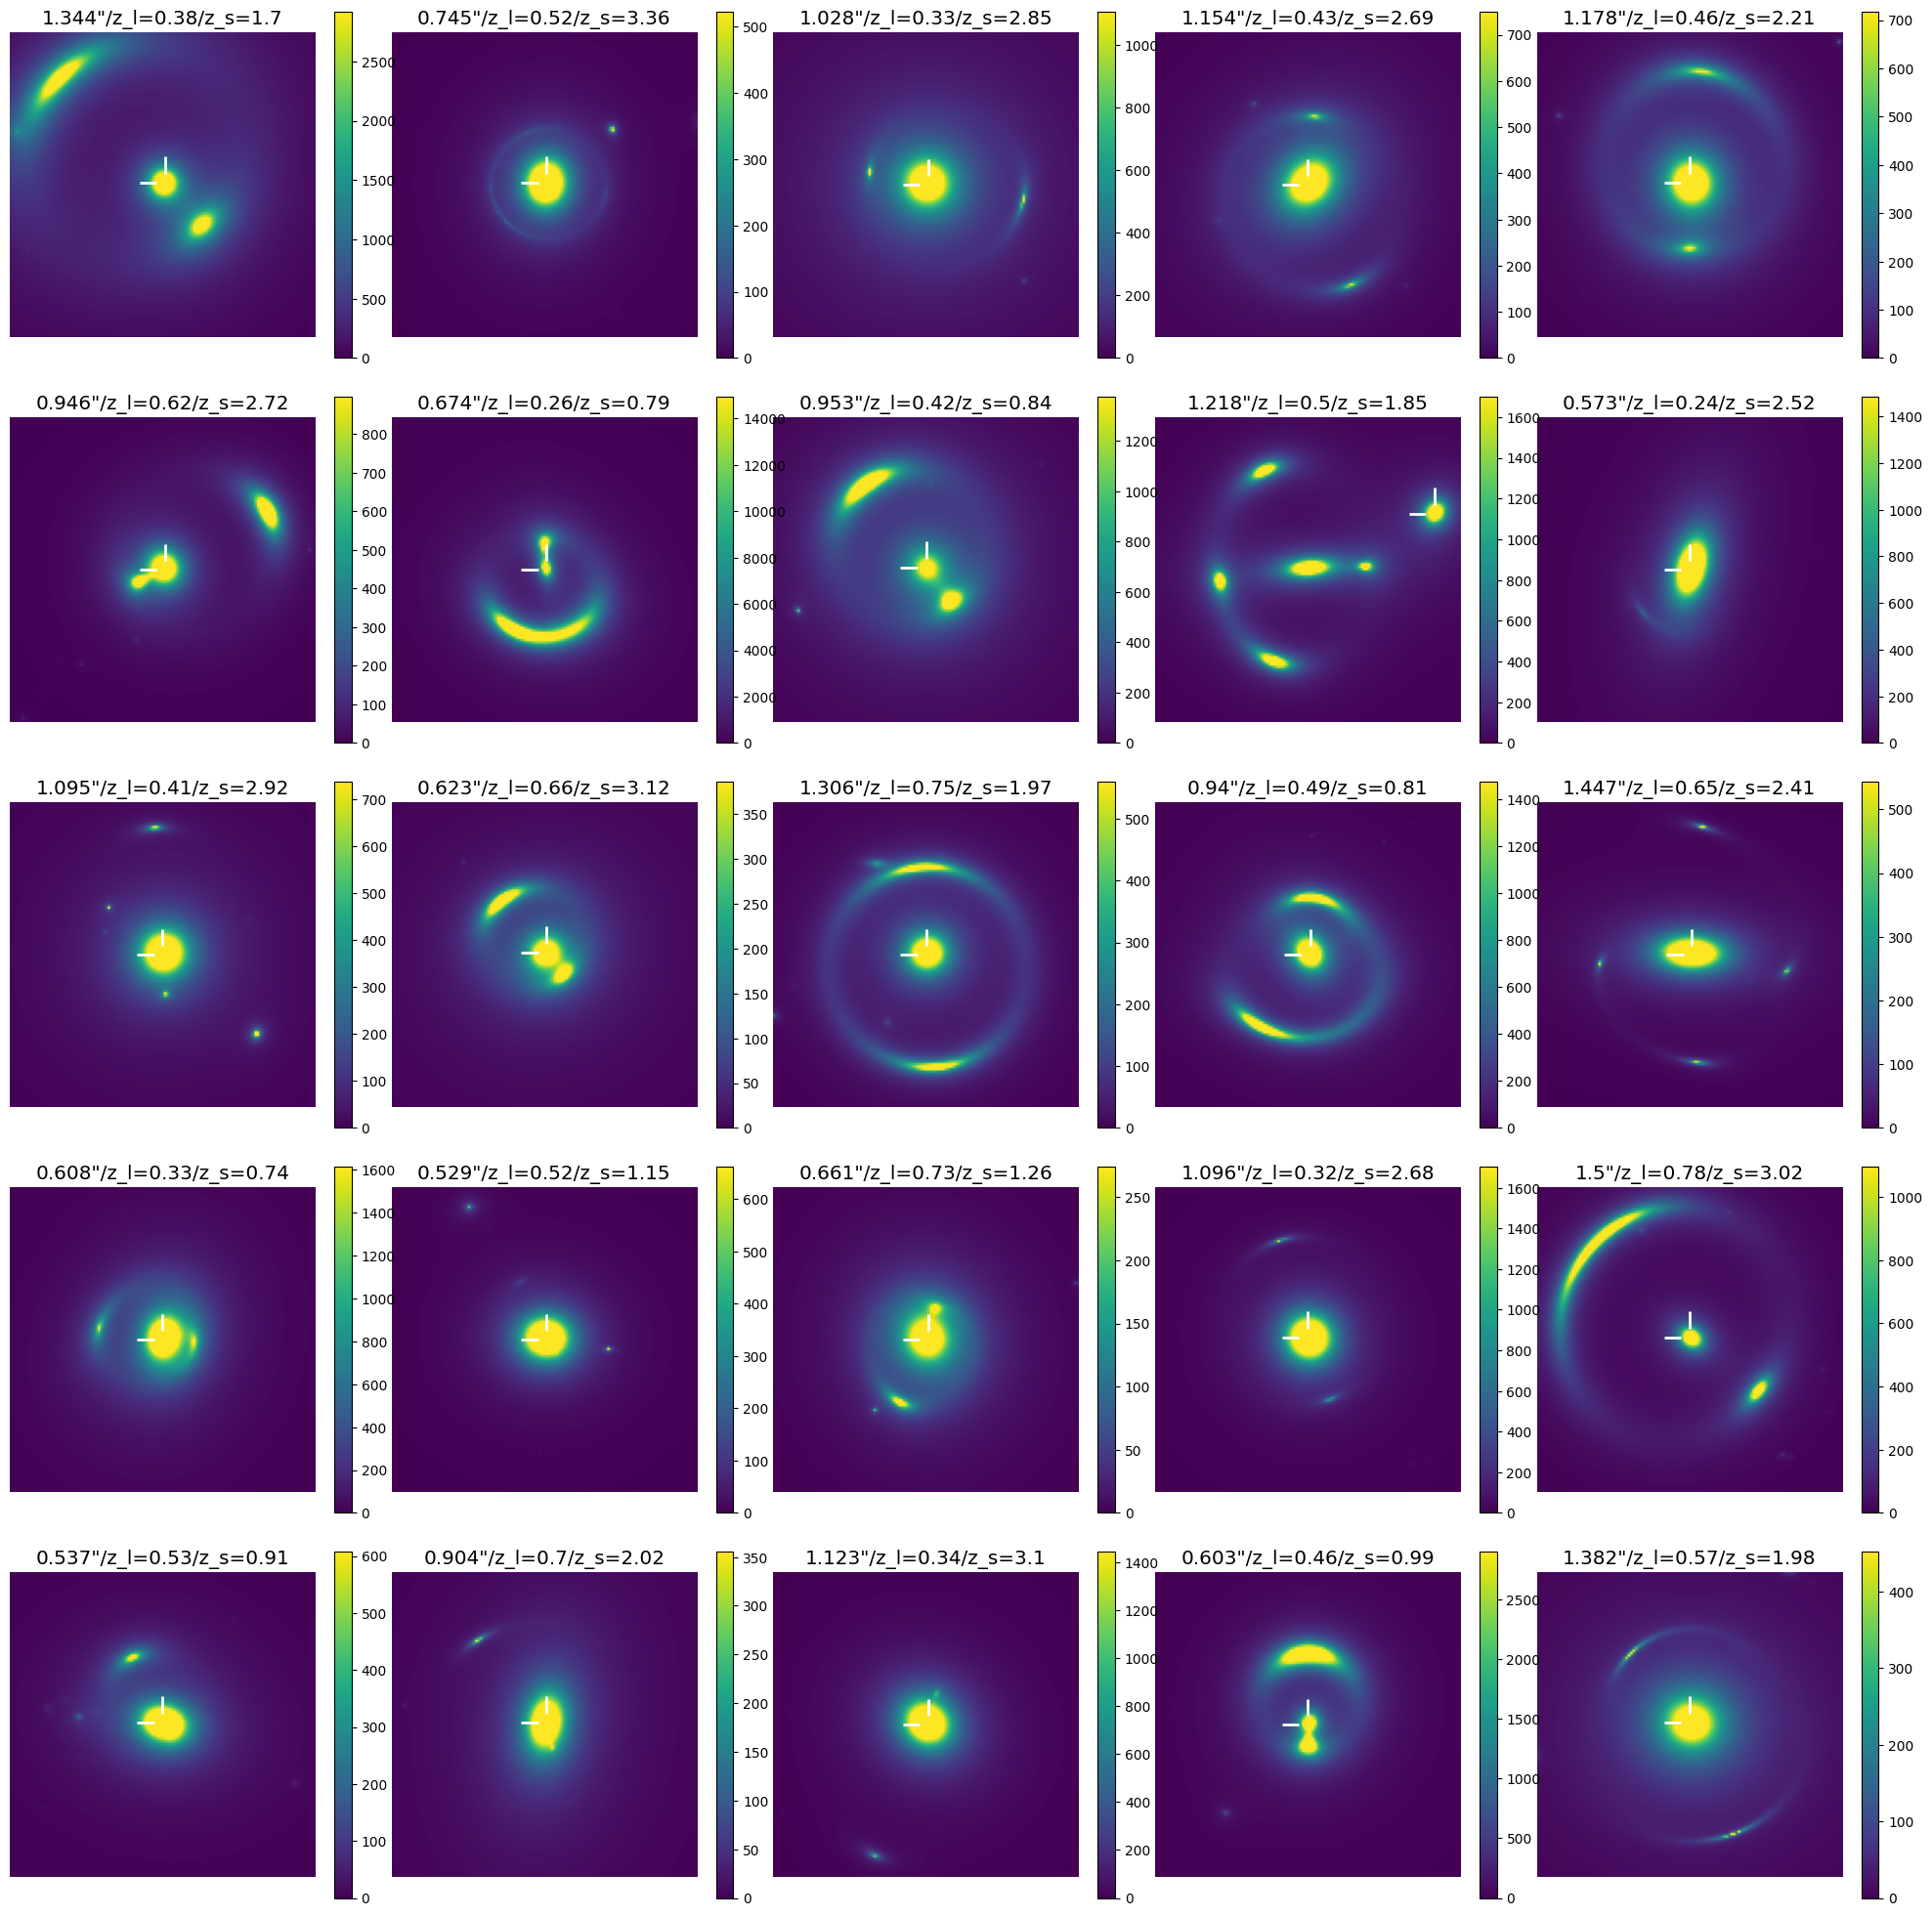

In [11]:
#5x5 test of simulation code
fig, axs = plt.subplots(5,5, dpi=100, figsize=(20,20))
background_rms=0
j = 0; np.random.seed(1)
for i in tqdm.tqdm(range(25)):
    image_real, _, theta_E, z_lens, z_source,image_source, unlensed_source, _, _ = simulate(exp_time=1200, lensed=True, sersic_source=True)    
    image_real += sim_background(exp_time=1200)
    
    im = axs[i//5,i%5].imshow(image_real, vmin=0, vmax = np.percentile(image_real,99), origin="lower")
    plt.colorbar(im,ax=axs[i//5,i%5],shrink=.9)
        
    axs[i//5,i%5].axis('off')
    axs[i//5,i%5].set_title(str(np.round(theta_E, 3))+'"/z_l='+str(np.round(z_lens,2))+"/z_s="+str(np.round(z_source,2)), fontsize="x-large")
    
    xl, yl = np.unravel_index(np.argmax(image_real-image_source),image_real.shape)
    axs[i//5,i%5].hlines(xl, yl-10.5,yl-3.5, color="white", linewidth=2)
    axs[i//5,i%5].vlines(yl, xl+3.5,xl+10.5, color="white", linewidth=2)

    i += 1
plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0);

In [ ]:
#Generates the images along with diagnostics files
import time
pixels = 125
start = time.time()
arr = np.concatenate([np.zeros(40000), np.ones(0)])
vsims = np.array(["vela35_"]*len(arr))
theta_Es, z_lens, z_source, image_source, unlensed_source, no_lens, mass, mStar = np.zeros(len(arr)), np.zeros(len(arr)), np.zeros(len(arr)), np.zeros((len(arr), pixels, pixels)), np.zeros((len(arr), pixels, pixels)), np.zeros((len(arr), pixels, pixels)), np.zeros(len(arr)), np.zeros(len(arr))
np.random.shuffle(arr)
background_rms=0; exp_time=1380
sersic_source=False
images = np.zeros((len(arr), pixels, pixels))
print('size:',size,", bkg:",background_rms)
for i in tqdm.tqdm(range(len(arr))):
    if arr[i] == 0:
        images[i], vsims[i], theta_Es[i], z_lens[i], z_source[i], image_source[i], unlensed_source[i], mass[i], mStar[i] = simulate(exp_time=exp_time,lensed=False)
    else:
        images[i], vsims[i], theta_Es[i], z_lens[i], z_source[i], image_source[i], unlensed_source[i], mass[i], mStar[i] = simulate(exp_time=exp_time,lensed=True, sersic_source=sersic_source)
    back_gals = get_real_background()
    images[i] += back_gals
    no_lens[i] = image_source[i] + back_gals


In [13]:
#Generates the images along with diagnostics files
import time
pixels = 125
start = time.time()
arr = np.concatenate([np.zeros(40000), np.ones(0)])
vsims = np.array(["vela35_"]*len(arr))
theta_Es, z_lens, z_source, image_source, unlensed_source, no_lens, mass, mStar = np.zeros(len(arr)), np.zeros(len(arr)), np.zeros(len(arr)), np.zeros((len(arr), pixels, pixels)), np.zeros((len(arr), pixels, pixels)), np.zeros((len(arr), pixels, pixels)), np.zeros(len(arr)), np.zeros(len(arr))
np.random.shuffle(arr)
background_rms=0; exp_time=1380
sersic_source=False
images = np.zeros((len(arr), pixels, pixels))
print('size:',size,", bkg:",background_rms)
for i in tqdm.tqdm(range(len(arr))):
    if arr[i] == 0:
        images[i], vsims[i], theta_Es[i], z_lens[i], z_source[i], image_source[i], unlensed_source[i], mass[i], mStar[i] = simulate(exp_time=exp_time,lensed=False)
    else:
        images[i], vsims[i], theta_Es[i], z_lens[i], z_source[i], image_source[i], unlensed_source[i], mass[i], mStar[i] = simulate(exp_time=exp_time,lensed=True, sersic_source=sersic_source)
    back_gals = sim_background(exp_time=exp_time)
    images[i] += back_gals
    no_lens[i] = image_source[i] + back_gals


size: .5-1.5 , bkg: 0


 80%|████████  | 32164/40000 [3:28:17<50:44,  2.57it/s]   


KeyboardInterrupt: 

In [ ]:
#Saves the files to path
# path = '/pscratch/sd/n/natekv/shielded'
# np.save(path+"/images", images)
# np.save(path+"/lensed", arr)
# np.save(path+"/vsims", vsims)
# np.save(path+"/theta_Es", theta_Es)
# np.save(path+"/masses", mass)
# np.save(path+"/mStar", mStar)
# np.save(path+"/z_lens", z_lens)
# np.save(path+"/z_source", z_source)
# np.save(path+"/image_source", image_source)
# np.save(path+"/no_lens", no_lens)
# np.save(path+"/unlensed_source",unlensed_source)
# time.time()-start

In [14]:
import os

path = '/pscratch/sd/n/natekv/shielded'
# path = ## add where you want to save them here

def append_and_save(filename, new_data):
    file_path = os.path.join(path, filename + ".npy")
    if os.path.exists(file_path):
        old_data = np.load(file_path)
        combined = np.concatenate((old_data, new_data), axis=0)
    else:
        combined = new_data
    np.save(file_path, combined)

# Example usage
append_and_save("images", images)
append_and_save("lensed", arr)
append_and_save("vsims", vsims)
append_and_save("theta_Es", theta_Es)
append_and_save("masses", mass)
append_and_save("mStar", mStar)
append_and_save("z_lens", z_lens)
append_and_save("z_source", z_source)
append_and_save("image_source", image_source)
append_and_save("no_lens", no_lens)
append_and_save("unlensed_source", unlensed_source)
time.time()-start

12616.397001981735

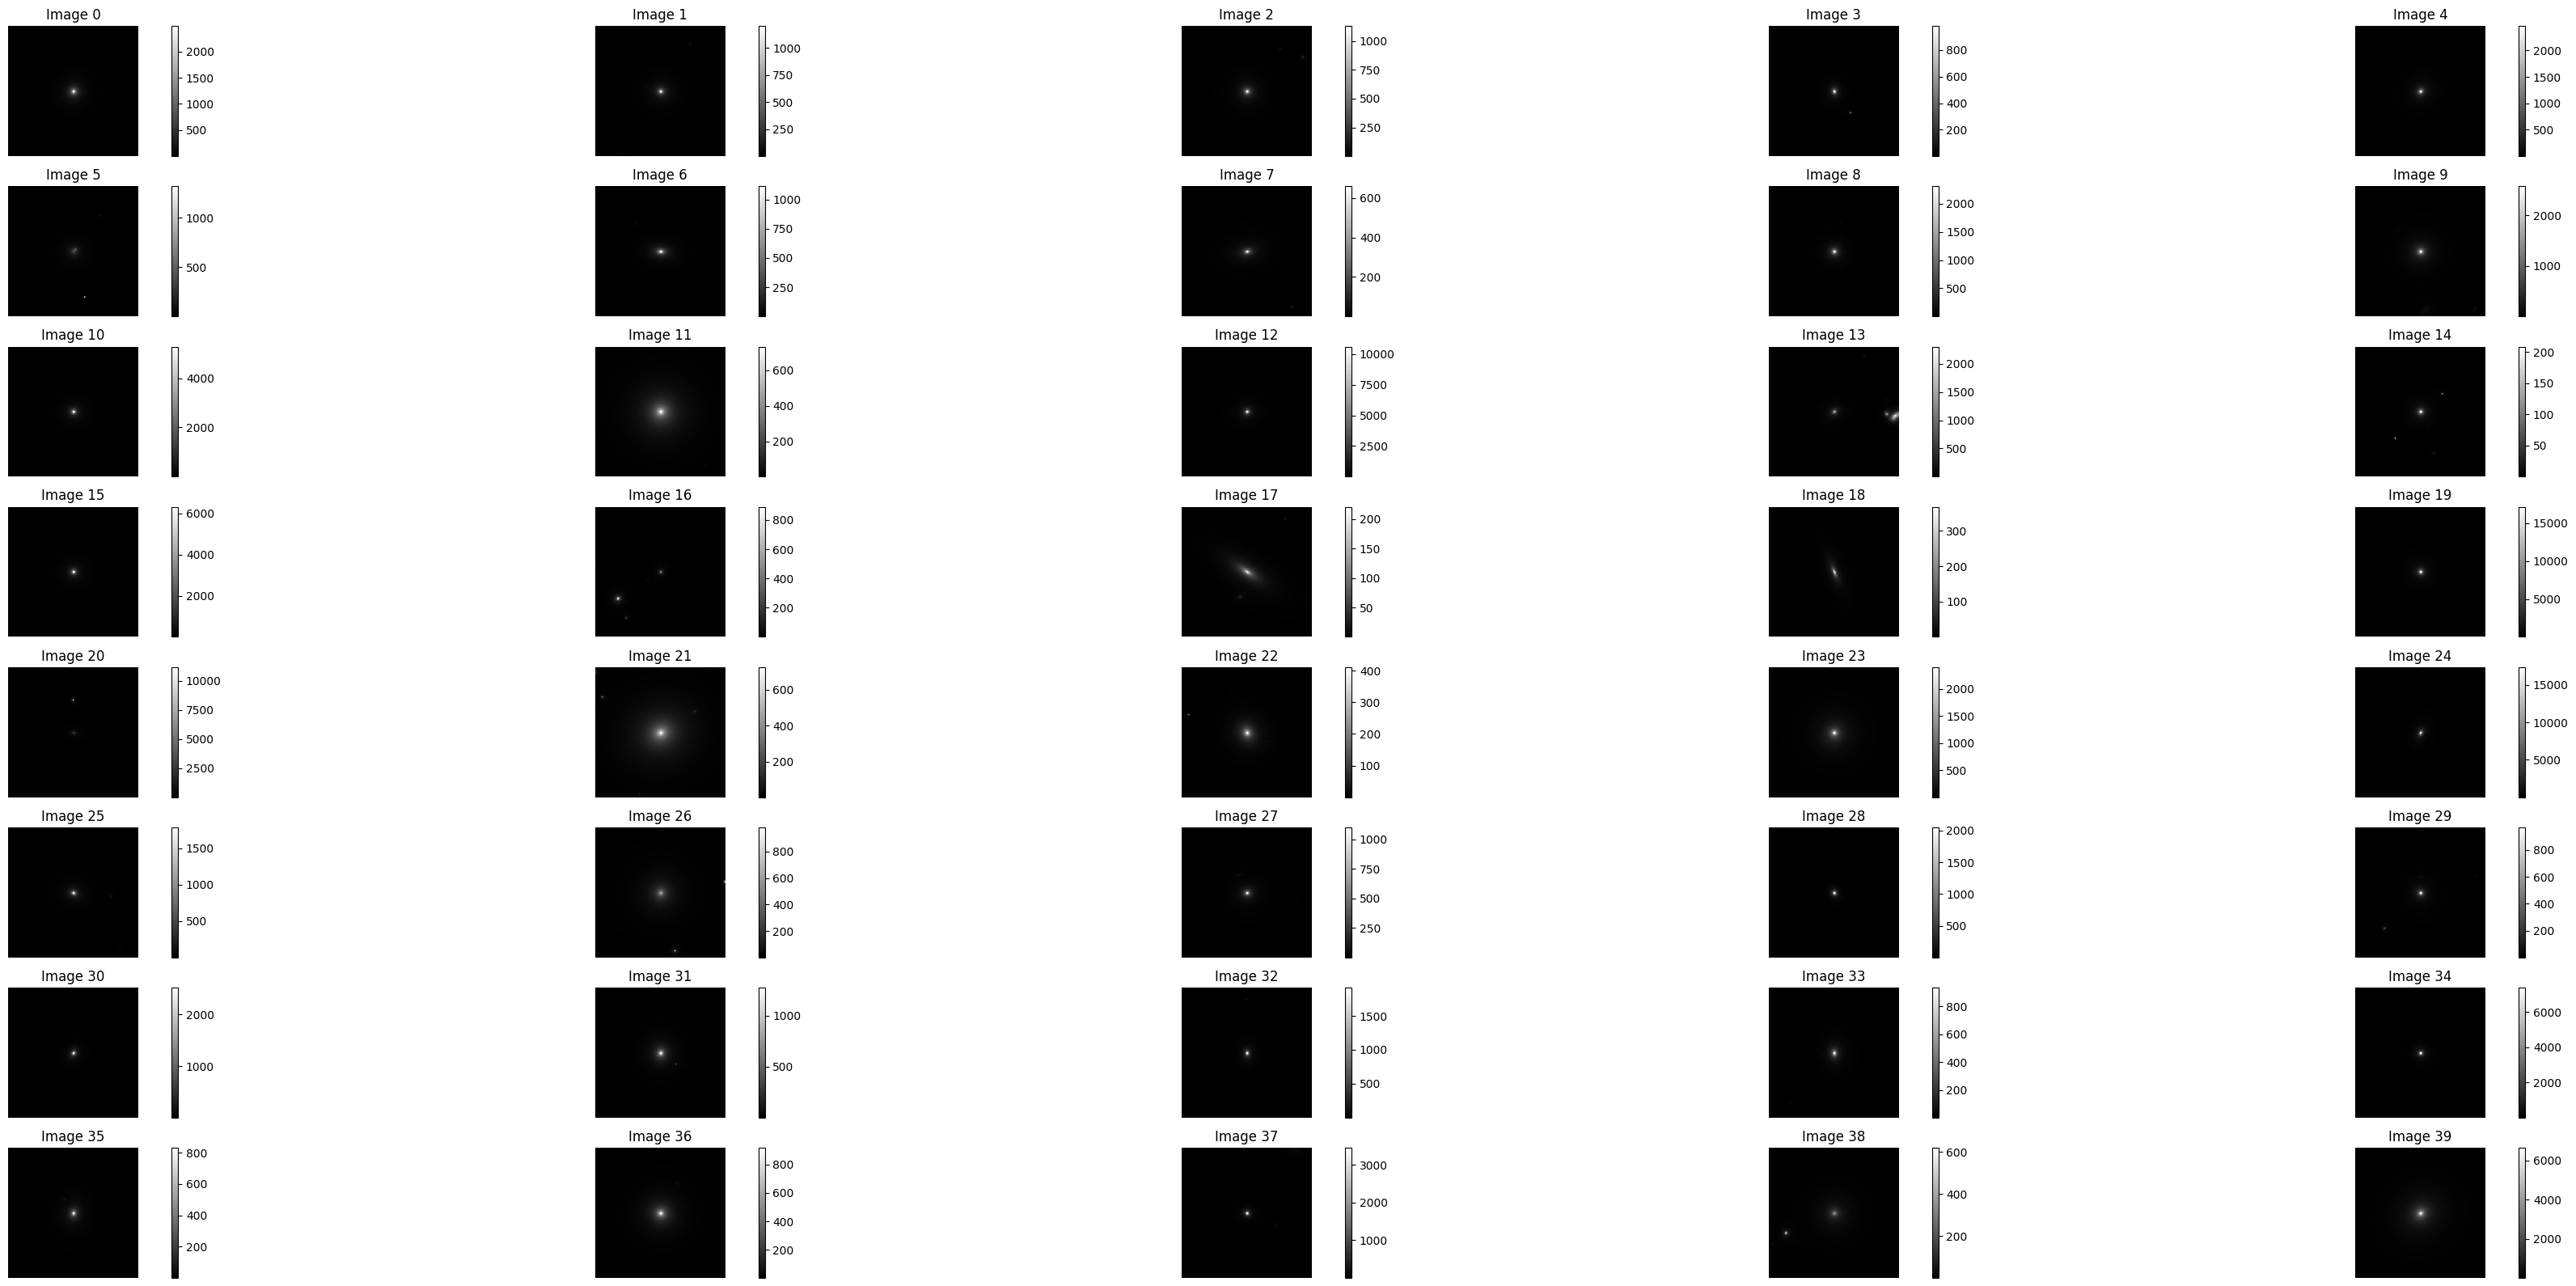

In [15]:
import numpy as np
import matplotlib.pyplot as plt
path = '/pscratch/sd/n/natekv/shielded'

images = np.load(f"{path}/images.npy")

# Show first 20 images with colorbars
plt.figure(figsize=(40, 16))  # Wider figure for more columns
for i in range(40):
    ax = plt.subplot(8, 5, i + 1)  # 4 rows, 5 columns
    im = ax.imshow(images[i], cmap='gray')  # Remove cmap if RGB
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('off')
    ax.set_title(f"Image {i}")

plt.tight_layout()
plt.show()

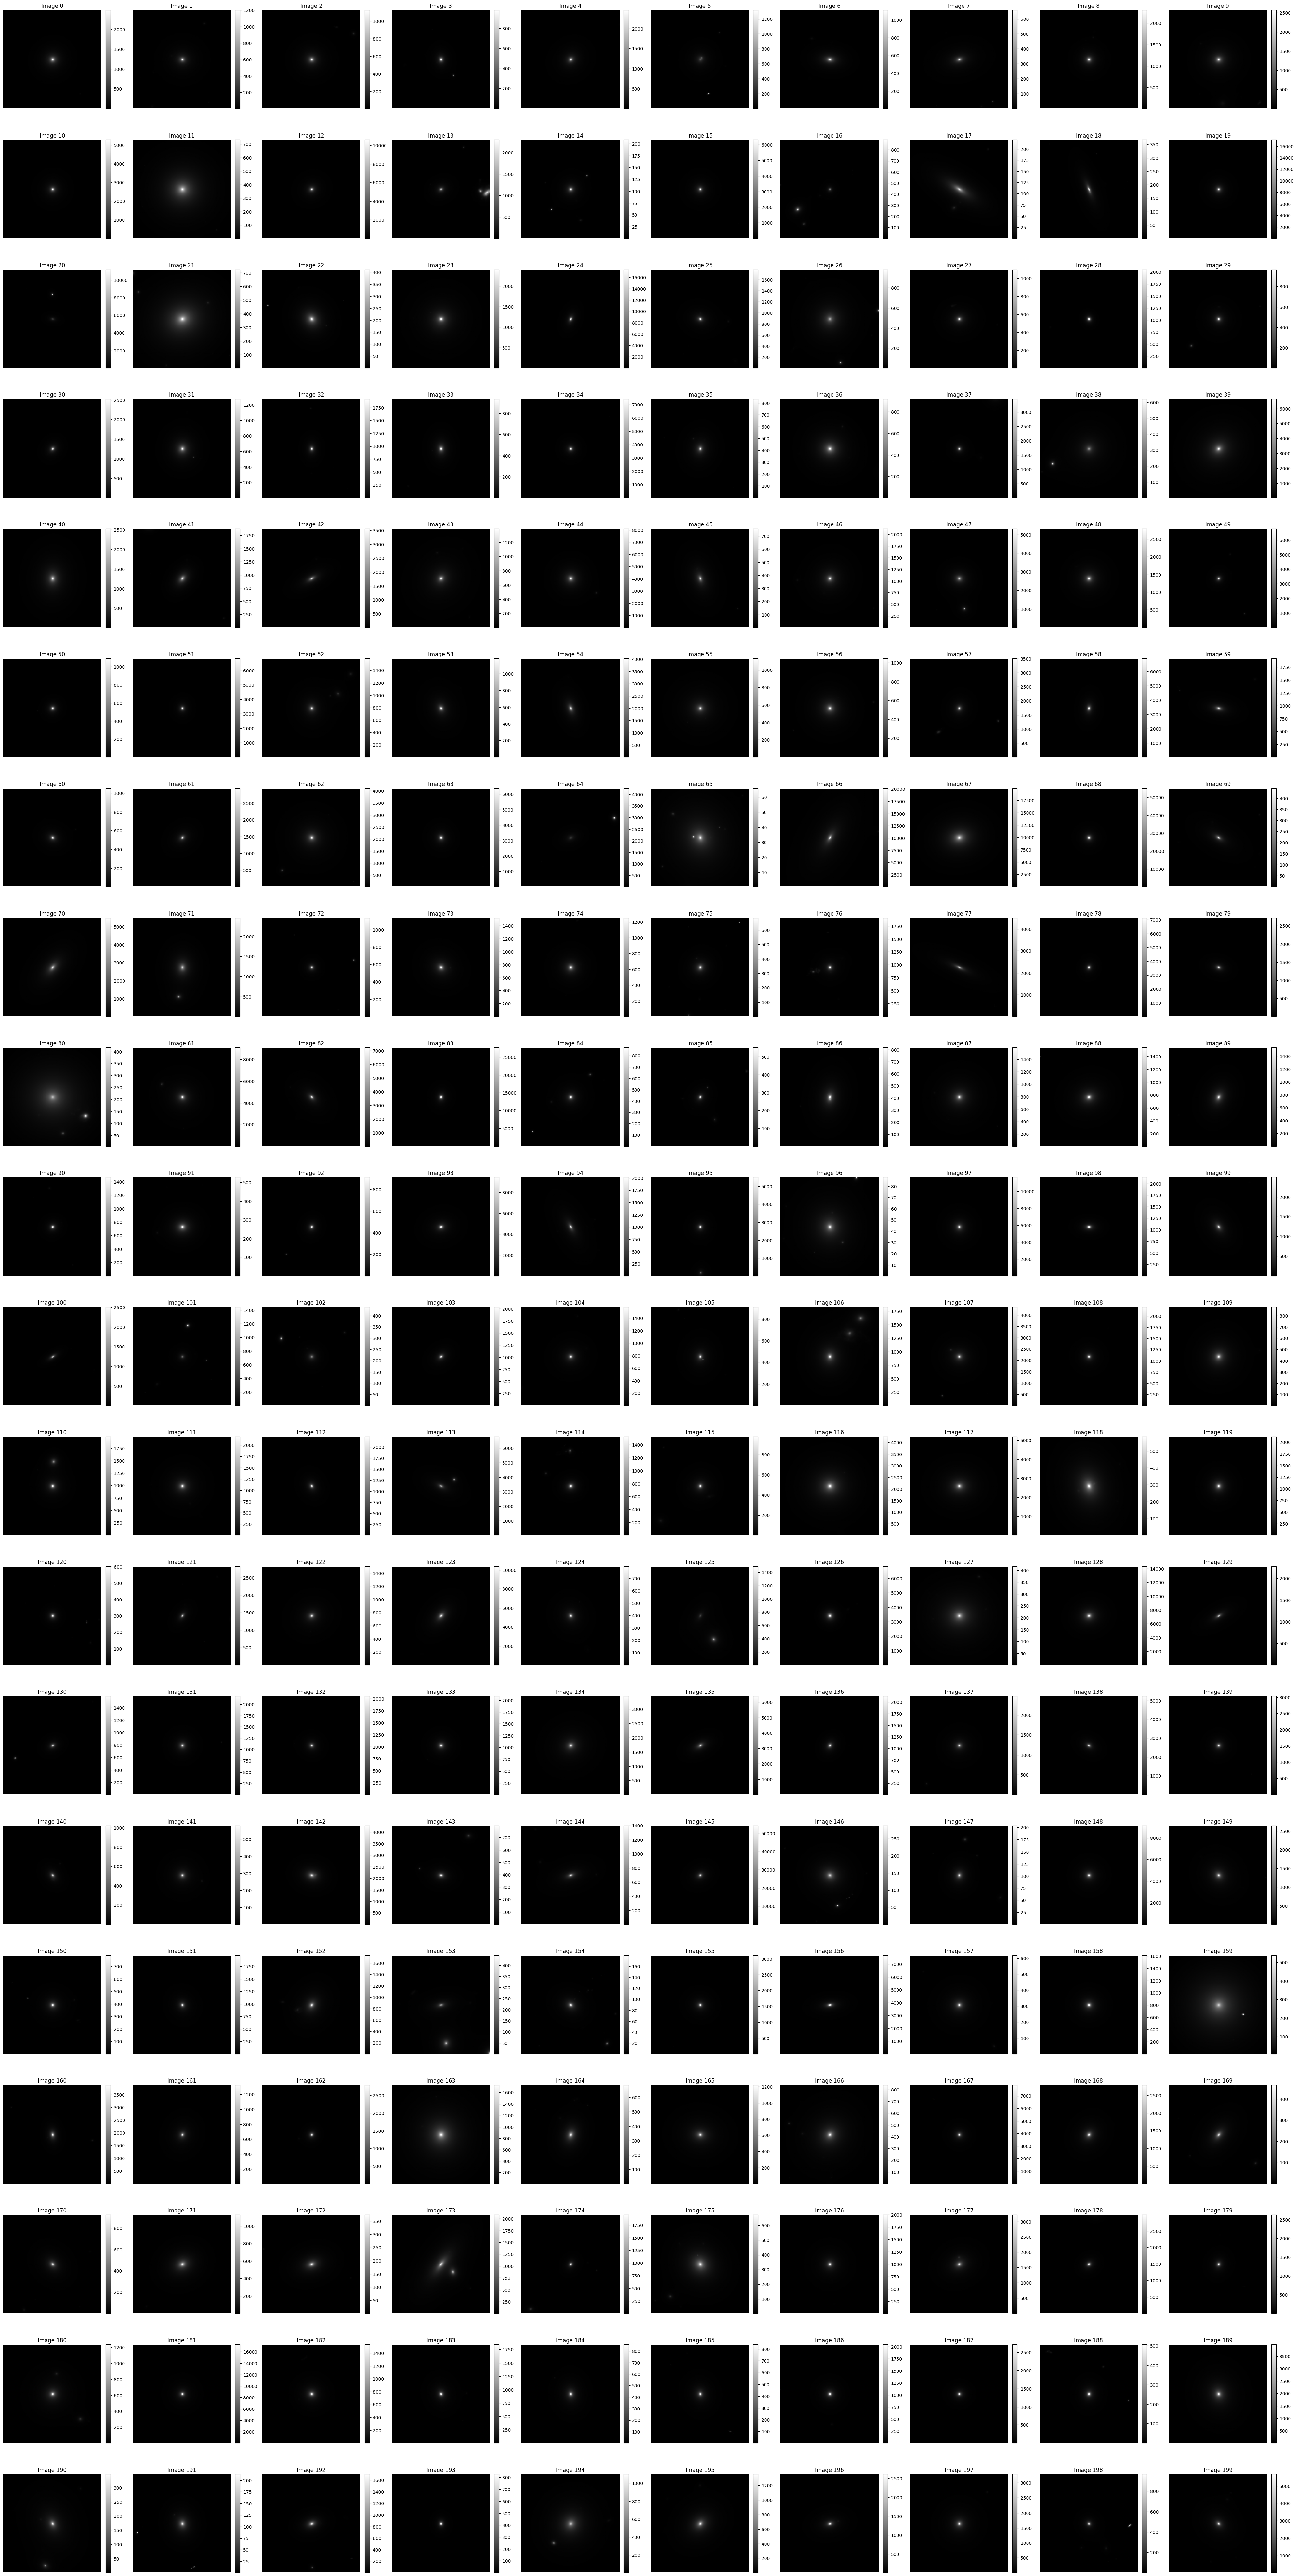

In [1]:
import numpy as np
import matplotlib.pyplot as plt

path = '/pscratch/sd/n/natekv/shielded'
images = np.load(f"{path}/images.npy")

# Show first 200 images with colorbars
plt.figure(figsize=(40, 80))  # Tall enough for 200 images
for i in range(200):
    ax = plt.subplot(20, 10, i + 1)  # 20 rows, 10 columns
    im = ax.imshow(images[i], cmap='gray')  # Remove cmap if RGB
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('off')
    ax.set_title(f"Image {i}")

plt.tight_layout()
plt.show()